### Integrantes:
- Valentina Giraldo Gaviria
- Sara Emanuelle Calderón


## **1. Carga de paquetes**

In [1]:
import pandas as pd
import numpy as np 
from statsmodels.sandbox.stats.runs import runstest_1samp # prueba de rachas de Wald y Wolfowitz
import statsmodels.api as sm # prueba de Box-Pierce y la modificación de Ljung-Box
from statsmodels.tsa.exponential_smoothing.ets import ETSModel
from matplotlib import pyplot as plt # gráficos 
import pylab as py
from scipy import stats
from datetime import datetime
from dateutil.relativedelta import relativedelta
from sklearn.metrics import mean_squared_error
import statsmodels.formula.api as smf
import seaborn as sns
from scipy import stats



### **2. Carga de los datos**

In [ ]:
data = pd.read_excel(r"Fundamentos de analitica\Series de tiempo/datosEmpleo.xlsx",index_col='mes',parse_dates=True)
data.head()

,TD_13ciudades,Ocupados,Desocupados,Inactivos
mes,,,,
2001-01-01,20.946380,6923.604,1834.507,4600.718
2001-02-01,19.894213,7037.746,1747.820,4596.805
2001-03-01,19.221565,6945.973,1652.823,4807.120
2001-04-01,17.888575,6973.079,1519.137,4937.280
2001-05-01,17.945654,6994.462,1529.720,4928.911


In [3]:
data.shape

(222, 4)

### **3. Protocolo de evaluación**

Es importante guardar una parte de la muestra para evaluar el comportamiento de los modelos por fuera de muestra (out-of-sample). 

En este caso se nos está pidiendo que generemos pronóstico para 6 meses. Por lo tanto, nuestro dataset de evaluación debería contener los últimos 6 meses, mientras que el dataset de entrenamiento debería contener el resto de los meses. En este caso, el dataset tiene 222 registros (meses). Así las cosas, nuestro dataset de evaluación serán 6 meses, mientras que nuestro dataset de entrenamiento será 216 meses (222 - 6).

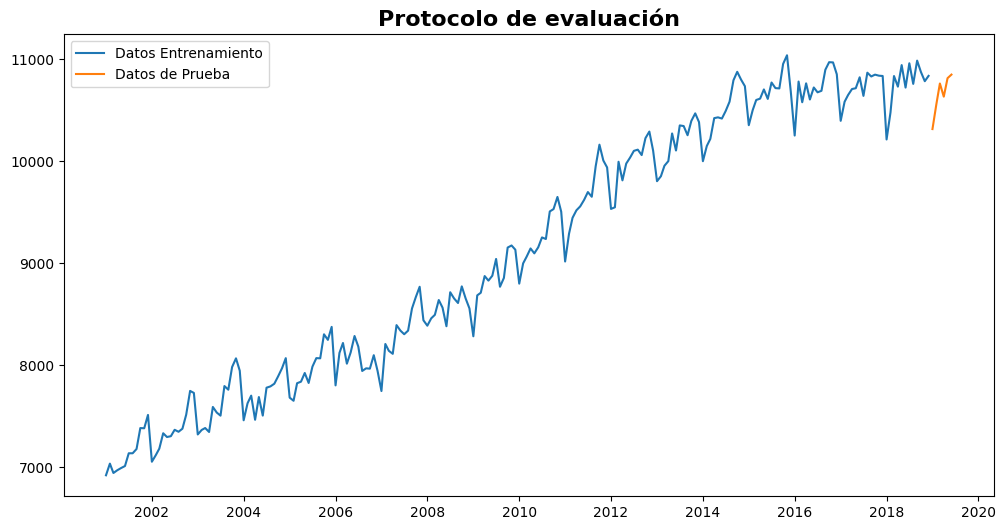

In [4]:
# Separamos un conjunto de entrenamiento y otro de prueba para evaluar pronóstico out-of-sample (6 meses).
train_len = 216
train_td = data[["Ocupados"]][:train_len]
test_td = data[["Ocupados"]][train_len:]

plt.figure(figsize=(12,6))
plt.title("Protocolo de evaluación",fontsize=16, fontweight='bold')
plt.plot(train_td,label="Datos Entrenamiento")
plt.plot(test_td,label="Datos de Prueba")
plt.legend()
plt.show()

## **4. Estimación de los modelos**

### **4.1 Tendencia lineal**

In [5]:
# Ajuste por Mínimos Cuadrados Ordinarios (OLS)

y = train_td["Ocupados"]
x = np.linspace(1,train_td.shape[0],train_td.shape[0])
X = sm.add_constant(x)
lin = sm.OLS(y,X)
lin_t = lin.fit()
print(lin_t.summary())

                            OLS Regression Results                            
Dep. Variable:               Ocupados   R-squared:                       0.962
Model:                            OLS   Adj. R-squared:                  0.962
Method:                 Least Squares   F-statistic:                     5386.
Date:                Sat, 08 Nov 2025   Prob (F-statistic):          1.10e-153
Time:                        14:16:29   Log-Likelihood:                -1500.2
No. Observations:                 216   AIC:                             3004.
Df Residuals:                     214   BIC:                             3011.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       6925.6150     34.477    200.879      0.0

Se grafican los residuales, se grafican los valores ajustados, y se realiza el pronóstico de los 6 meses con el modelo ajustado.

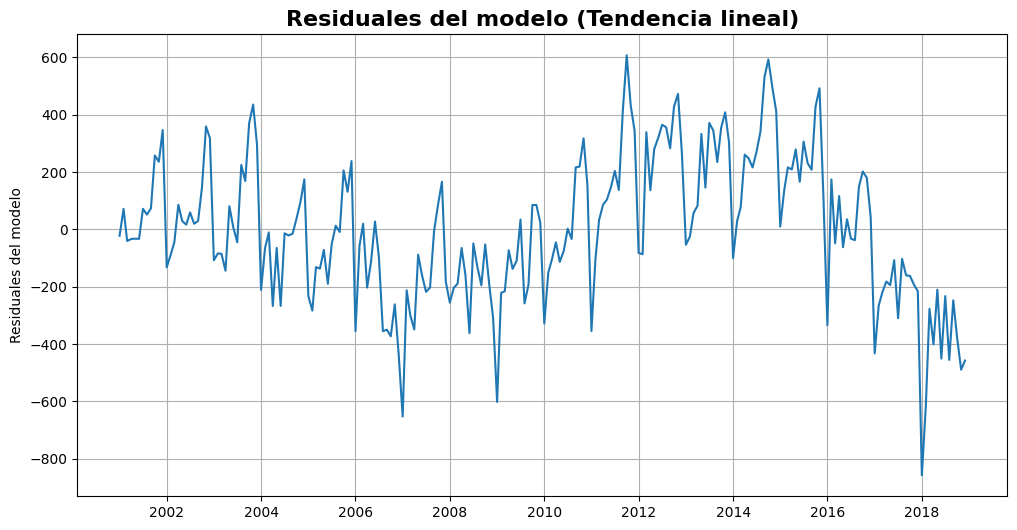

In [6]:
# Residuales del modelo lineal

fig = plt.figure(figsize=(12, 6))
plt.title("Residuales del modelo (Tendencia lineal)",fontsize=16, fontweight='bold')
plt.ylabel("Residuales del modelo")
plt.plot(lin_t.resid)
plt.grid()

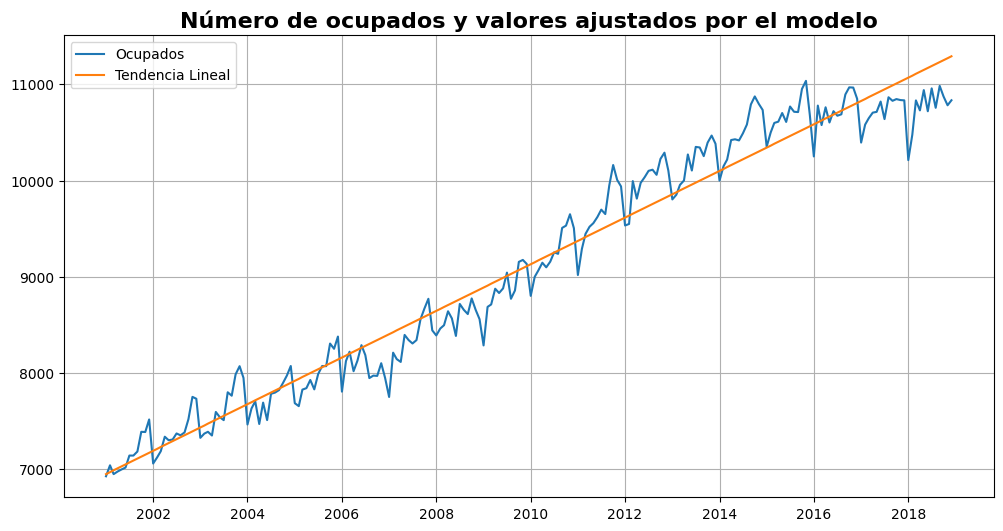

In [7]:
# Valores ajustados vs observados

fig = plt.figure(figsize=(12, 6))
plt.title("Número de ocupados y valores ajustados por el modelo",fontsize=16, fontweight='bold')
plt.plot(y,label="Ocupados")
plt.plot(lin_t.fittedvalues,label="Tendencia Lineal")
plt.legend()
plt.grid()
plt.show()

In [8]:
# Horizonte de pronóstico (h=6)

h=6
x_for= np.linspace((train_td.shape[0]+1),(train_td.shape[0]+h),h)
X_for= sm.add_constant(x_for)

In [9]:
# Intervalos de predicción al 95%

dt = lin_t.get_prediction(X_for).summary_frame(alpha = 0.05)
y_prd_lin = dt['mean']
yprd_ci_lower = dt['obs_ci_lower']
yprd_ci_upper = dt['obs_ci_upper']
preds = pd.DataFrame(np.column_stack([y_prd_lin, yprd_ci_lower, yprd_ci_upper]))
preds.columns = ['Point_forecast', 'lower_95', 'upper_95']
print(preds)

   Point_forecast      lower_95      upper_95
0    11313.116341  10810.849071  11815.383612
1    11333.335242  10831.003977  11835.666506
2    11353.554142  10851.158304  11855.949979
3    11373.773042  10871.312053  11876.234030
4    11393.991942  10891.465223  11896.518660
5    11414.210842  10911.617816  11916.803868


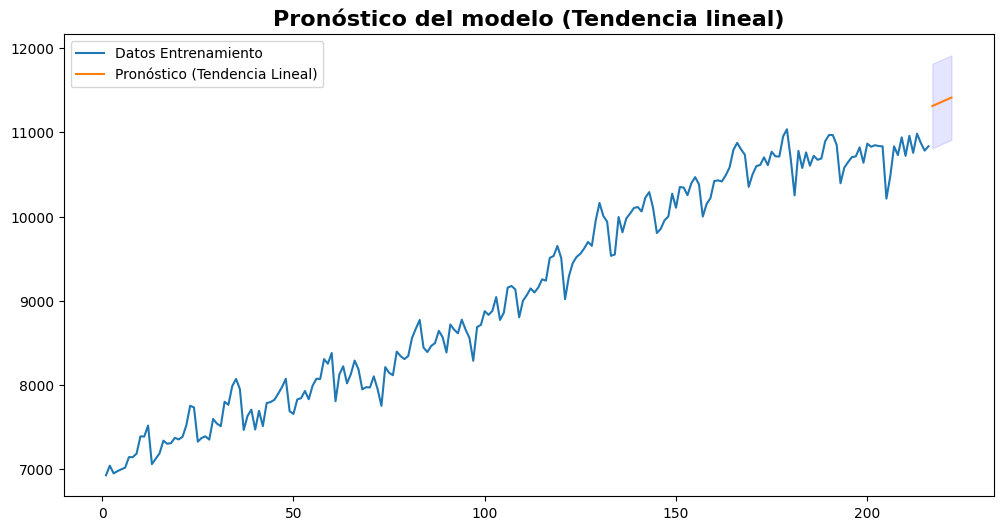

In [10]:
# Gráfico de pronóstico lineal

fig = plt.figure(figsize=(12, 6))
plt.title("Pronóstico del modelo (Tendencia lineal)",fontsize=16, fontweight='bold')
plt.plot(x,y,label="Datos Entrenamiento")
plt.plot(x_for,preds['Point_forecast'],label="Pronóstico (Tendencia Lineal)")
plt.fill_between(x_for ,preds['lower_95'], preds['upper_95'], color='blue', alpha=0.1)
plt.legend()
plt.show()


Con el modelo ajustado, se procede a calcular el RMSE en el dataset de prueba.

In [11]:
# RMSE en el set de prueba

rmse_lin = np.sqrt(mean_squared_error(test_td, y_prd_lin))
print(f"RMSE del modelo tendencia lineal: {rmse_lin:.4f}")

RMSE del modelo tendencia lineal: 725.5285


### **4.2 Tendencia Cuadrática**

In [12]:
y = train_td["Ocupados"]

# Creamos features de tendencia polinómica (grado 2)
train_td["x"] = np.linspace(1,train_td.shape[0],train_td.shape[0])
train_td["x2"] = train_td["x"] ** 2

# Matriz de diseño con intercepto
X = sm.add_constant(train_td[["x","x2"]])

# Ajuste OLS
pol = sm.OLS(y,X)
pol_2 = pol.fit()
print(pol_2.summary())

                            OLS Regression Results                            
Dep. Variable:               Ocupados   R-squared:                       0.963
Model:                            OLS   Adj. R-squared:                  0.962
Method:                 Least Squares   F-statistic:                     2752.
Date:                Sat, 08 Nov 2025   Prob (F-statistic):          6.85e-153
Time:                        14:16:30   Log-Likelihood:                -1497.5
No. Observations:                 216   AIC:                             3001.
Df Residuals:                     213   BIC:                             3011.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       6835.5053     51.482    132.774      0.0

Se grafican los residuales, se grafican los valores ajustados, y se realiza el pronóstico de los 6 meses con el modelo ajustado.

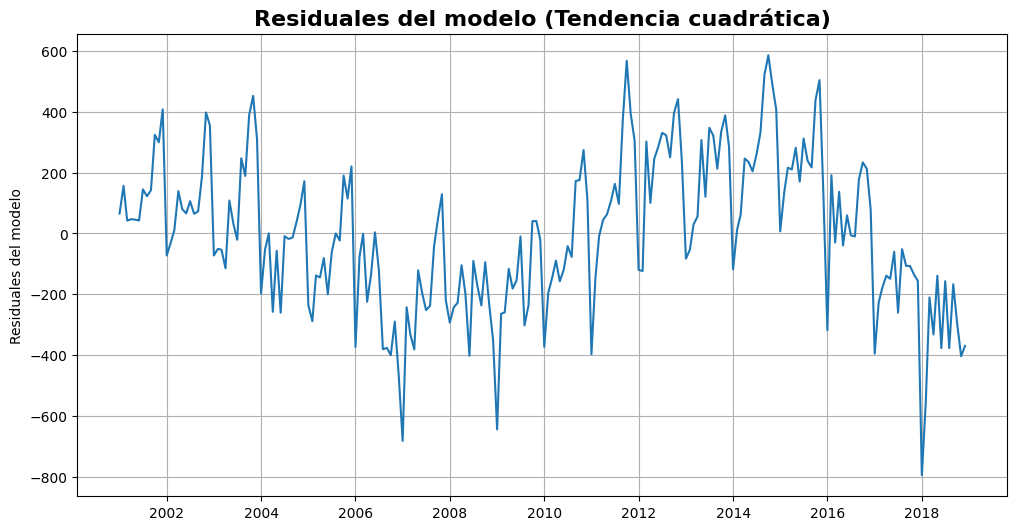

In [13]:
# Residuales

fig = plt.figure(figsize=(12, 6))
plt.title("Residuales del modelo (Tendencia cuadrática)",fontsize=16, fontweight='bold')
plt.ylabel("Residuales del modelo")
plt.plot(pol_2.resid)
plt.grid()

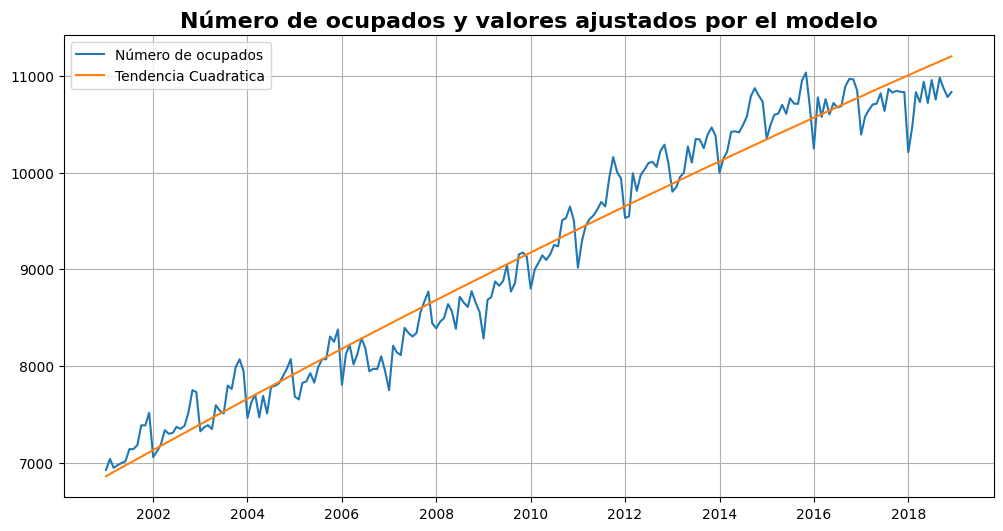

In [14]:
# Ajuste vs observado

fig = plt.figure(figsize=(12, 6))
plt.title("Número de ocupados y valores ajustados por el modelo",fontsize=16, fontweight='bold')
plt.plot(y,label="Número de ocupados")
plt.plot(pol_2.fittedvalues,label="Tendencia Cuadratica")
plt.legend()
plt.grid()
plt.show()

In [15]:
# Pronóstico a 6 meses

h=6
x_for= np.linspace((train_td.shape[0]+1),(train_td.shape[0]+h),h)
X_for= sm.add_constant(np.stack((x_for, x_for**2), axis=1))

In [16]:
# Intervalos de predicción

dt = pol_2.get_prediction(X_for).summary_frame(alpha = 0.05)
y_prd_cuadri = dt['mean']
yprd_ci_lower = dt['obs_ci_lower']
yprd_ci_upper = dt['obs_ci_upper']
preds = pd.DataFrame(np.column_stack([y_prd_cuadri, yprd_ci_lower, yprd_ci_upper]))
preds.columns = ['Point_forecast', 'lower_95', 'upper_95']
print(preds)

   Point_forecast      lower_95      upper_95
0    11223.006575  10720.110033  11725.903118
1    11240.733961  10737.453096  11744.014826
2    11258.438489  10754.761188  11762.115790
3    11276.120159  10772.034093  11780.206225
4    11293.778971  10789.271596  11798.286346
5    11311.414925  10806.473482  11816.356368


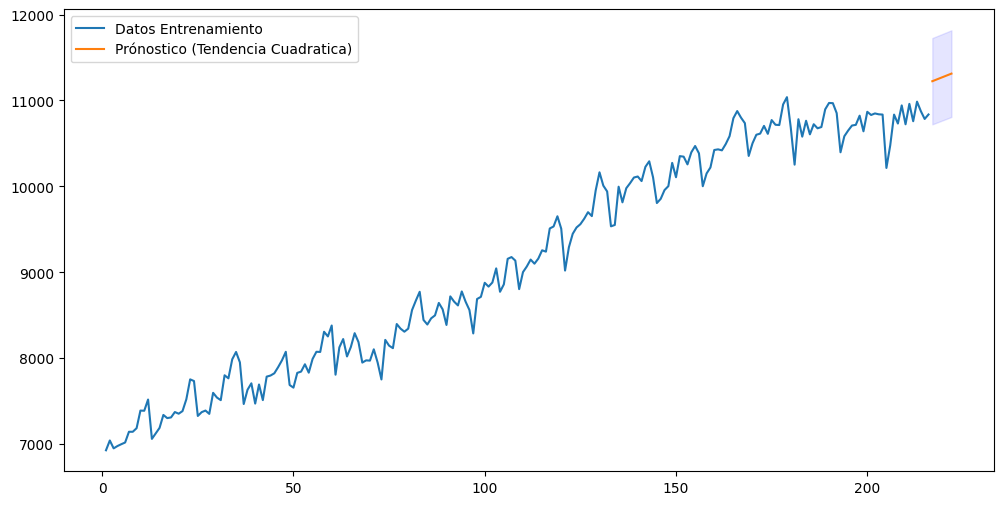

In [17]:
# Gráfico de pronóstico cuadrático

fig = plt.figure(figsize=(12, 6))
plt.plot(x,y,label="Datos Entrenamiento")
plt.plot(x_for,preds['Point_forecast'],label="Prónostico (Tendencia Cuadratica)")
plt.fill_between(x_for ,preds['lower_95'], preds['upper_95'], color='blue', alpha=0.1)
plt.legend()
plt.show()

Con el modelo ajustado, se procede a calcular el RMSE en el dataset de prueba.

In [18]:
# RMSE sobre prueba

rmse_cuadri = np.sqrt(mean_squared_error(test_td, y_prd_cuadri))
print(f"RMSE del modelo tendencia cuadrática: {rmse_cuadri:.4f}")

RMSE del modelo tendencia cuadrática: 632.4767


### **4.3 Estacionalidad**

Se hace la dummificación de los meses

In [19]:
# Dummificación de los meses para TODA la serie, alineada por índice temporal

month_dummies = pd.get_dummies(data.index.month,drop_first=True).set_index(data.index)

Se procede hacer el split del dataset, esta vez tanto el set de entrenamiento como el de prueba incluye las dummys

In [20]:
# Rehacemos split (train/test) para esta especificación

train_len = 216
train_td = data[["Ocupados"]][:train_len]
test_td = data[["Ocupados"]][train_len:]

In [21]:
# X de entrenamiento y prueba con constante

X_train = sm.add_constant(month_dummies.loc[train_td.index]).astype(float)
X_test  = sm.add_constant(month_dummies.loc[test_td.index]).astype(float)

In [22]:
# Ajuste OLS sólo con estacionalidad

y = train_td["Ocupados"]
X = X_train
sea = sm.OLS(y,X)
season = sea.fit()
print(season.summary())

                            OLS Regression Results                            
Dep. Variable:               Ocupados   R-squared:                       0.021
Model:                            OLS   Adj. R-squared:                 -0.032
Method:                 Least Squares   F-statistic:                    0.3897
Date:                Sat, 08 Nov 2025   Prob (F-statistic):              0.959
Time:                        14:16:31   Log-Likelihood:                -1850.6
No. Observations:                 216   AIC:                             3725.
Df Residuals:                     204   BIC:                             3766.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       8724.5387    308.558     28.275      0.0

In [23]:
month_dummies

,2,3,4,5,6,7,8,9,10,11,12
mes,,,,,,,,,,,
2001-01-01,False,False,False,False,False,False,False,False,False,False,False
2001-02-01,True,False,False,False,False,False,False,False,False,False,False
2001-03-01,False,True,False,False,False,False,False,False,False,False,False
2001-04-01,False,False,True,False,False,False,False,False,False,False,False
2001-05-01,False,False,False,True,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
2019-02-01,True,False,False,False,False,False,False,False,False,False,False
2019-03-01,False,True,False,False,False,False,False,False,False,False,False
2019-04-01,False,False,True,False,False,False,False,False,False,False,False


Se grafican los residuales, se grafican los valores ajustados, y se realiza el pronóstico de los 6 meses con el modelo ajustado.

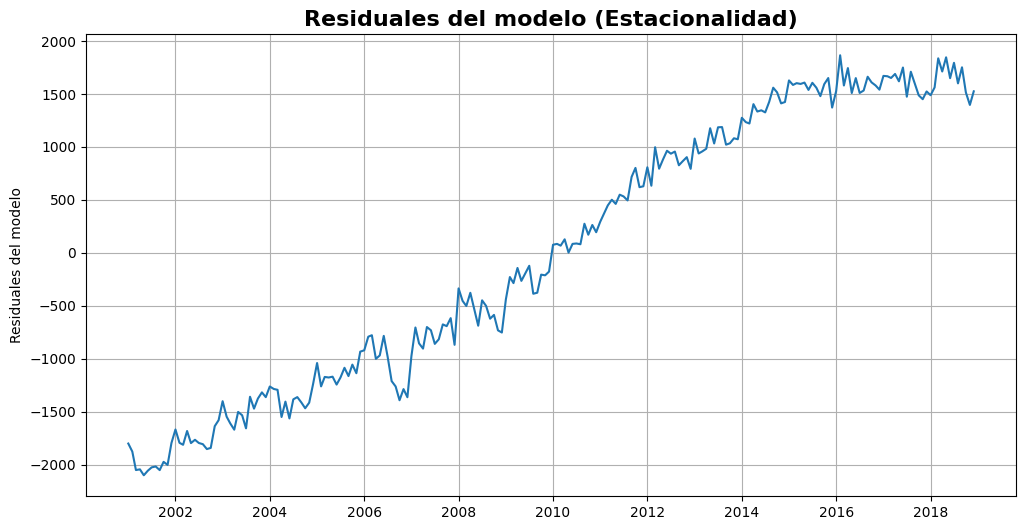

In [24]:
# Residuales
fig = plt.figure(figsize=(12, 6))
plt.title("Residuales del modelo (Estacionalidad)",fontsize=16, fontweight='bold')
plt.ylabel("Residuales del modelo")
plt.plot(season.resid)
plt.grid()

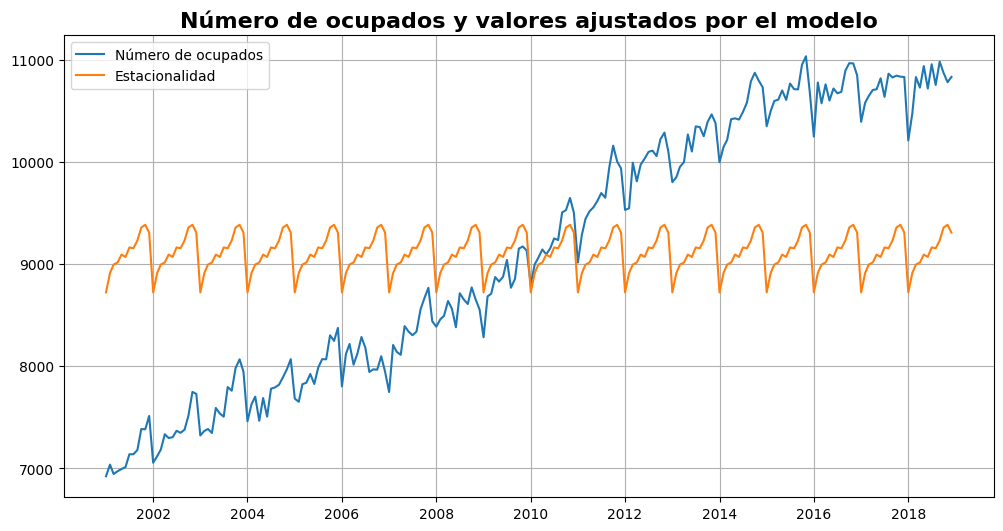

In [25]:
# Ajuste vs observado

fig = plt.figure(figsize=(12, 6))
plt.title("Número de ocupados y valores ajustados por el modelo",fontsize=16, fontweight='bold')
plt.plot(y,label="Número de ocupados")
plt.plot(season.fittedvalues,label="Estacionalidad")
plt.legend()
plt.grid()
plt.show()

In [26]:
# Construimos matriz X para los próximos h meses respetando la codificación de columnas

range_dates = pd.date_range(X_train.index[-1]+ relativedelta(months=1), periods=6,freq='MS')

x_for = pd.get_dummies(pd.Index(range_dates.month, name='month'), drop_first=True)
x_for.index = range_dates

# Asegurar mismas columnas (y orden) que el modelo entrenado

cols_exog = season.model.exog_names           
exog_cols = [c for c in cols_exog if c != 'const']

x_for = x_for.reindex(columns=exog_cols, fill_value=0).astype('float64')

X_for = sm.add_constant(x_for, has_constant='add').astype('float64')

In [27]:
# Predicción e intervalos

dt = season.get_prediction(X_for).summary_frame(alpha = 0.05)
y_prd_estaci = dt['mean']
yprd_ci_lower = dt['obs_ci_lower']
yprd_ci_upper = dt['obs_ci_upper']
preds = pd.DataFrame(np.column_stack([y_prd_estaci, yprd_ci_lower, yprd_ci_upper]))
preds.columns = ['Point_forecast', 'lower_95', 'upper_95']
preds.set_index(range_dates,inplace=True)
print(preds)

            Point_forecast     lower_95      upper_95
2019-01-01     8724.538722  6072.708767  11376.368678
2019-02-01     8914.544389  6262.714433  11566.374344
2019-03-01     8997.218333  6345.388378  11649.048289
2019-04-01     9017.681722  6365.851767  11669.511678
2019-05-01     9095.089000  6443.259045  11746.918955
2019-06-01     9071.789000  6419.959045  11723.618955


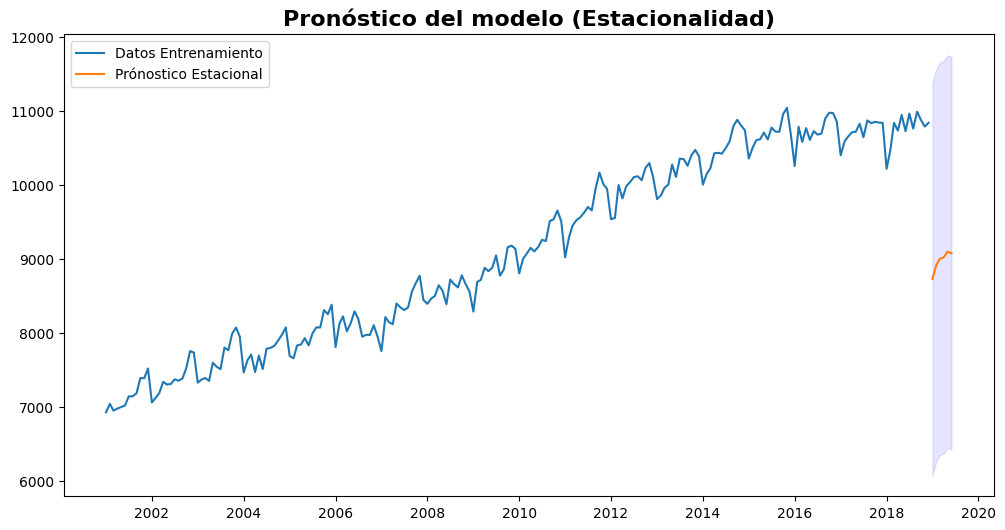

In [28]:
# Gráfico pronóstico estacional

fig = plt.figure(figsize=(12, 6))
plt.title("Pronóstico del modelo (Estacionalidad)",fontsize=16, fontweight='bold')
plt.plot(y.index,y,label="Datos Entrenamiento")
plt.plot(preds.index,preds['Point_forecast'],label="Prónostico Estacional")
plt.fill_between(preds.index,preds['lower_95'], preds['upper_95'], color='blue', alpha=0.1)
plt.legend()
plt.show()

Con el modelo ajustado, se procede a calcular el RMSE en el dataset de prueba.

In [29]:
# RMSE en prueba

rmse_estaci = np.sqrt(mean_squared_error(test_td, y_prd_estaci))
print(f"RMSE del modelo con solo estacionalidad: {rmse_estaci:.4f}")

RMSE del modelo con solo estacionalidad: 1685.7662


### **4.4 Tendencia cuadrática + Estacionalidad**

In [30]:
# Volvemos a crear dummies y splits para seguridad

month_dummies = pd.get_dummies(data.index.month,drop_first=True).set_index(data.index)

train_len = 216
train_td = data[["Ocupados"]][:train_len]
test_td = data[["Ocupados"]][train_len:]

# Tendencia cuadrática en train

train_td["x"] = np.linspace(1,train_td.shape[0],train_td.shape[0])
train_td["x2"] = train_td["x"] ** 2

# Matriz X = [const, x, x2, dummies de mes]

X_train = pd.concat([train_td[["x","x2"]],month_dummies.reindex(train_td.index)],axis=1)
X_train = sm.add_constant(X_train, has_constant="add").astype("float64")

In [31]:
# Ajuste OLS con tendencia+estacionalidad

y = train_td["Ocupados"]
X = X_train
Season_pol2 = sm.OLS(y,X)
Season_pol_2= Season_pol2.fit()
print(Season_pol_2.summary())

                            OLS Regression Results                            
Dep. Variable:               Ocupados   R-squared:                       0.971
Model:                            OLS   Adj. R-squared:                  0.970
Method:                 Least Squares   F-statistic:                     528.1
Date:                Sat, 08 Nov 2025   Prob (F-statistic):          4.37e-148
Time:                        14:16:32   Log-Likelihood:                -1468.9
No. Observations:                 216   AIC:                             2966.
Df Residuals:                     202   BIC:                             3013.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       6562.0204     68.138     96.304      0.0

In [32]:
X

,const,x,x2,2,3,4,5,6,7,8,9,10,11,12
mes,,,,,,,,,,,,,,
2001-01-01,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2001-02-01,1.0,2.0,4.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2001-03-01,1.0,3.0,9.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2001-04-01,1.0,4.0,16.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2001-05-01,1.0,5.0,25.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-08-01,1.0,212.0,44944.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2018-09-01,1.0,213.0,45369.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2018-10-01,1.0,214.0,45796.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


Se grafican los residuales, se grafican los valores ajustados, y se realiza el pronóstico de los 6 meses con el modelo ajustado.

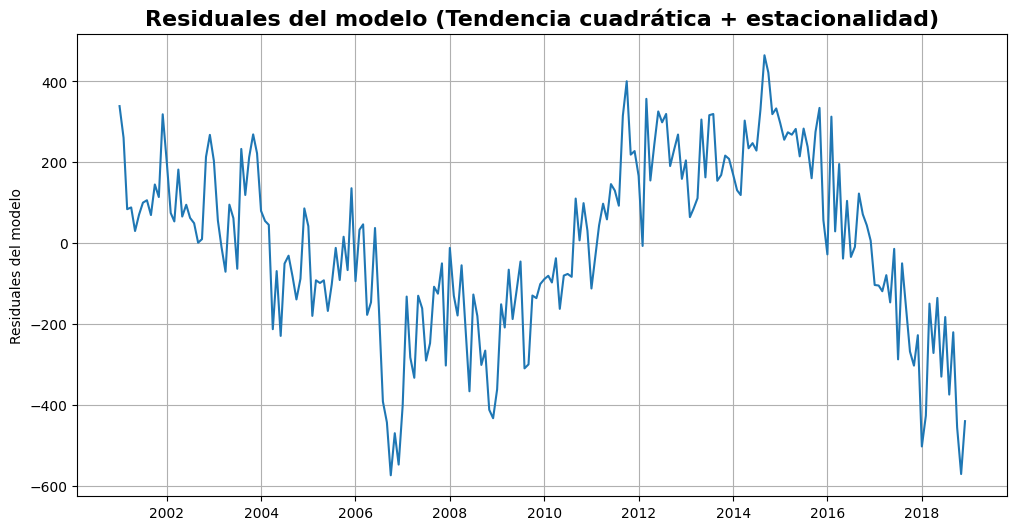

In [33]:
#Residuales

fig = plt.figure(figsize=(12, 6))
plt.title("Residuales del modelo (Tendencia cuadrática + estacionalidad)",fontsize=16, fontweight='bold')
plt.ylabel("Residuales del modelo")
plt.plot(Season_pol_2.resid)
plt.grid()

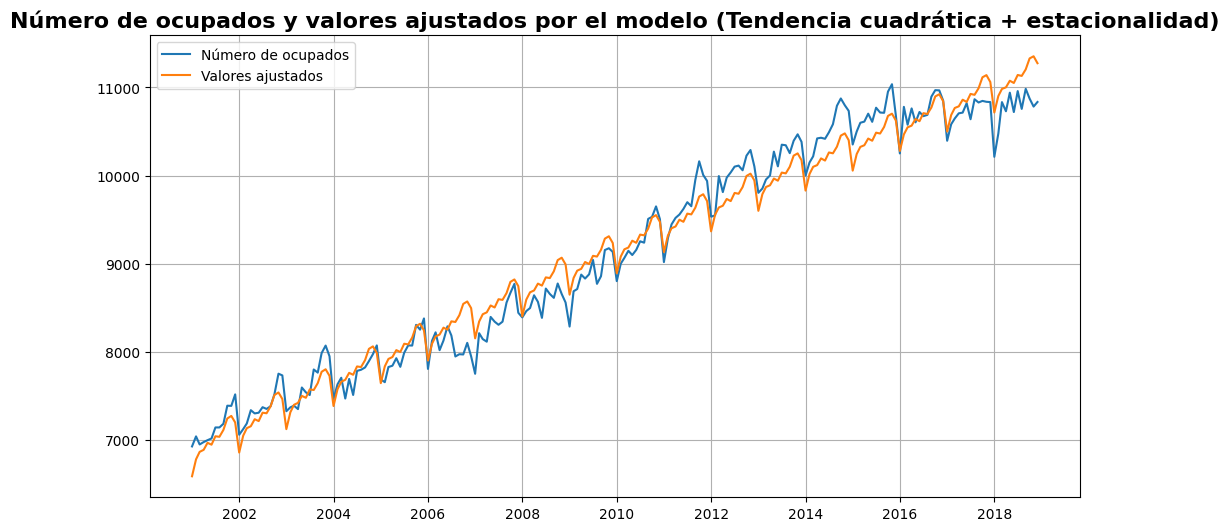

In [34]:
#Ajuste

fig = plt.figure(figsize=(12, 6))
plt.title("Número de ocupados y valores ajustados por el modelo (Tendencia cuadrática + estacionalidad)",fontsize=16, fontweight='bold')
plt.plot(y,label="Número de ocupados")
plt.plot(Season_pol_2.fittedvalues,label="Valores ajustados")
plt.legend()
plt.grid()
plt.show()

In [35]:
# --- Pronóstico a h ---

# 1) Construimos valores de tendencia futura

x_for= np.linspace((train_td.shape[0]+1),(train_td.shape[0]+h),h)

range_dates = pd.date_range(X_train.index[-1]+ relativedelta(months=1), periods=6,freq='MS')

x_for_all = pd.DataFrame(np.stack((x_for, x_for**2),axis=1), index=range_dates,columns=["x","x2"] )

# 2) Dummies futuras con mismas columnas del modelo entrenado

x_for_dummies = pd.get_dummies(pd.Index(range_dates.month, name='month'), drop_first=True)
x_for_dummies.index = range_dates
x_for_dummies = x_for_dummies.astype("float64")


exog_cols = [c for c in Season_pol_2.model.exog_names if c != "const"]
trend_cols = [c for c in exog_cols if c in ("x","x2")]
dummy_cols = [c for c in exog_cols if c not in ("x","x2")]

x_for_dum = x_for_dummies.reindex(columns=dummy_cols, fill_value=0)

X_for = pd.concat([x_for_all[trend_cols], x_for_dum], axis=1).reindex(columns=exog_cols)
X_for = sm.add_constant(X_for, has_constant='add').astype('float64')

In [36]:
# 3) Predicción e intervalos

dt = Season_pol_2.get_prediction(X_for).summary_frame(alpha = 0.05)
y_prd_estaci_lin = dt['mean']
yprd_ci_lower = dt['obs_ci_lower']
yprd_ci_upper = dt['obs_ci_upper']
preds = pd.DataFrame(np.column_stack([y_prd_estaci_lin, yprd_ci_lower, yprd_ci_upper]))
preds.columns = ['Point_forecast', 'lower_95', 'upper_95']
preds.set_index(range_dates,inplace=True)
print(preds)

            Point_forecast      lower_95      upper_95
2019-01-01    10928.984636  10465.310322  11392.658951
2019-02-01    11116.389734  10652.420472  11580.358996
2019-03-01    11196.463110  10732.190668  11660.735551
2019-04-01    11214.325929  10749.742094  11678.909765
2019-05-01    11289.132638  10824.229209  11754.036068
2019-06-01    11263.232069  10798.000864  11728.463274


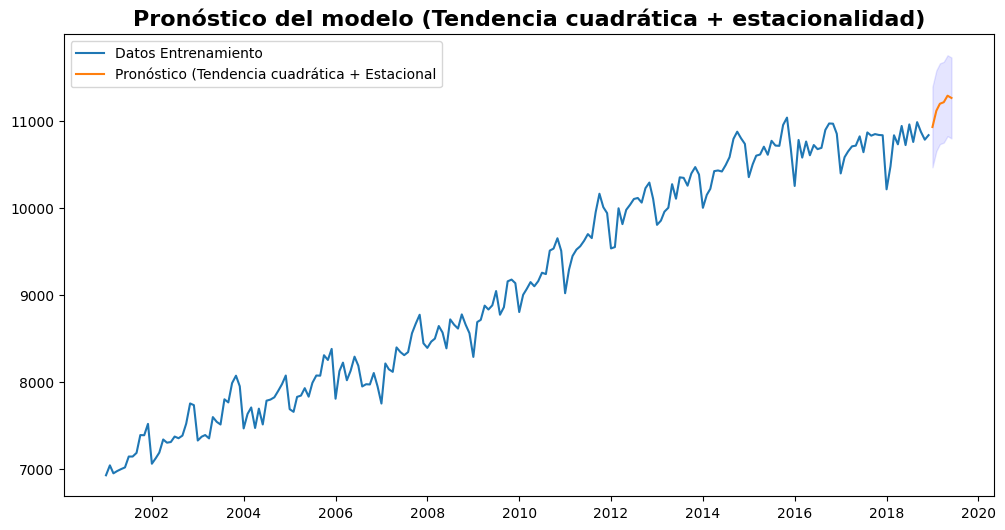

In [37]:
# Visual pronósticos

fig = plt.figure(figsize=(12, 6))
plt.title("Pronóstico del modelo (Tendencia cuadrática + estacionalidad)",fontsize=16, fontweight='bold')
plt.plot(y.index,y,label="Datos Entrenamiento")
plt.plot(preds.index,preds['Point_forecast'],label="Pronóstico (Tendencia cuadrática + Estacional")
plt.fill_between(preds.index,preds['lower_95'], preds['upper_95'], color='blue', alpha=0.1)
plt.legend()
plt.show()

Con el modelo ajustado, se procede a calcular el RMSE en el dataset de prueba.

In [38]:
# RMSE

rmse_estaci_lin2 = np.sqrt(mean_squared_error(test_td, y_prd_estaci_lin))
print(f"RMSE del modelo tendencia cuadrática + Estacional: {rmse_estaci_lin2:.4f}")

RMSE del modelo tendencia cuadrática + Estacional: 519.2259


### **4.5 Tendencia polinómica (orden 3) + estacionalidad**

In [39]:
train_td["x3"] = train_td["x"] ** 3

# Matriz X con x, x2, x3 y dummies
X_train = pd.concat([train_td[["x","x2","x3"]],month_dummies.reindex(train_td.index)],axis=1)

# Añadir constante y asegurar float
X_train = sm.add_constant(X_train, has_constant="add").astype("float64")

In [40]:
# Ajuste OLS

y = train_td["Ocupados"]
X = X_train
Season_pol3 = sm.OLS(y,X)
Season_pol_3= Season_pol3.fit()
print(Season_pol_3.summary())

                            OLS Regression Results                            
Dep. Variable:               Ocupados   R-squared:                       0.987
Model:                            OLS   Adj. R-squared:                  0.986
Method:                 Least Squares   F-statistic:                     1096.
Date:                Sat, 08 Nov 2025   Prob (F-statistic):          2.56e-181
Time:                        14:16:33   Log-Likelihood:                -1383.2
No. Observations:                 216   AIC:                             2796.
Df Residuals:                     201   BIC:                             2847.
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       6980.7137     53.194    131.232      0.0

In [41]:
X

,const,x,x2,x3,2,3,4,5,6,7,8,9,10,11,12
mes,,,,,,,,,,,,,,,
2001-01-01,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2001-02-01,1.0,2.0,4.0,8.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2001-03-01,1.0,3.0,9.0,27.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2001-04-01,1.0,4.0,16.0,64.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2001-05-01,1.0,5.0,25.0,125.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-08-01,1.0,212.0,44944.0,9528128.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2018-09-01,1.0,213.0,45369.0,9663597.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2018-10-01,1.0,214.0,45796.0,9800344.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


Se grafican los residuales, se grafican los valores ajustados, y se realiza el pronóstico de los 6 meses con el modelo ajustado.

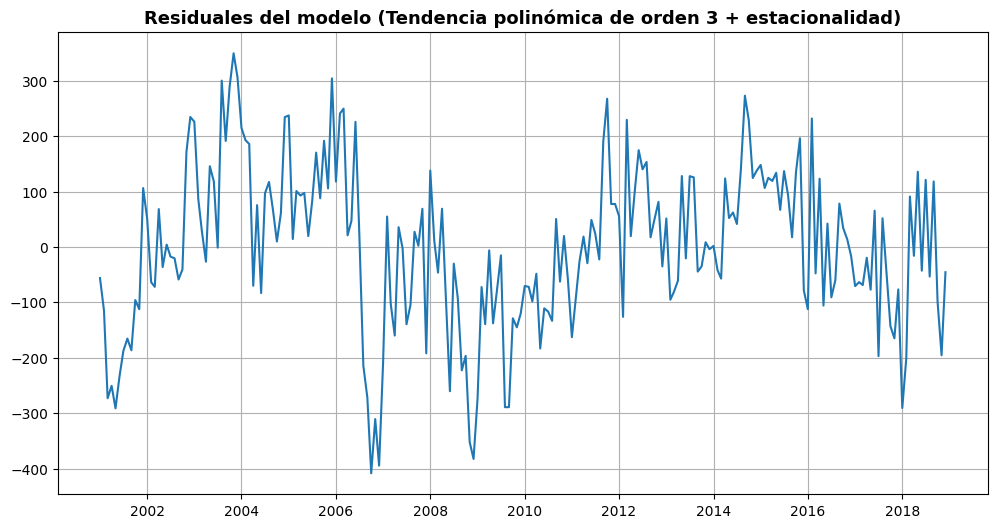

In [42]:
#Residuales

fig = plt.figure(figsize=(12, 6))
plt.title("Residuales del modelo (Tendencia polinómica de orden 3 + estacionalidad)",fontsize=13, fontweight='bold')
plt.plot(Season_pol_3.resid)
plt.grid()

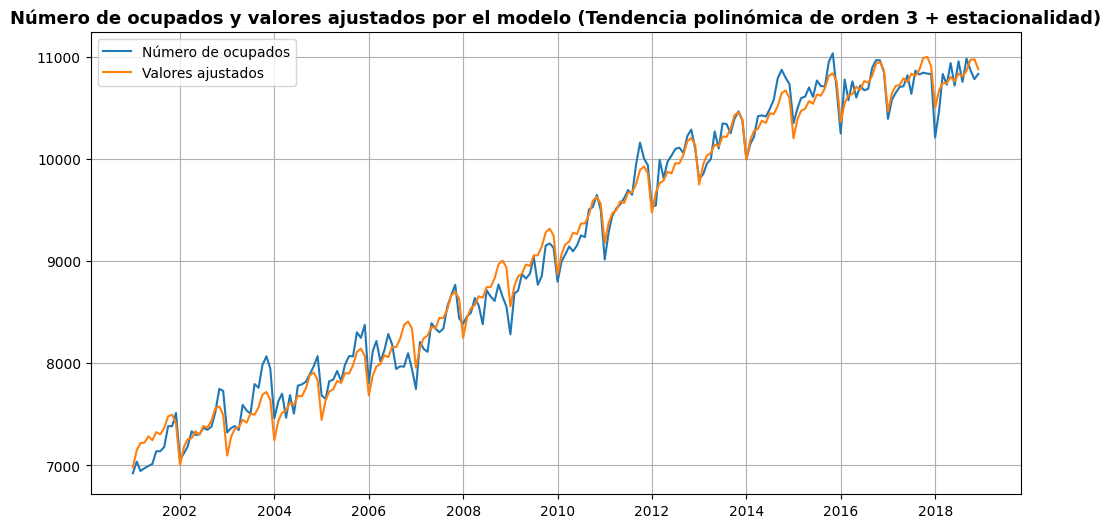

In [43]:
#Ajuste

fig = plt.figure(figsize=(12, 6))
plt.title("Número de ocupados y valores ajustados por el modelo (Tendencia polinómica de orden 3 + estacionalidad)",fontsize=13, fontweight='bold')
plt.plot(y,label="Número de ocupados")
plt.plot(Season_pol_3.fittedvalues,label="Valores ajustados")
plt.legend()
plt.grid()
plt.show()

In [44]:
# Pronóstico 6 meses

x_for= np.linspace((train_td.shape[0]+1),(train_td.shape[0]+h),h)

range_dates = pd.date_range(X_train.index[-1]+ relativedelta(months=1), periods=6,freq='MS')

x_for_all = pd.DataFrame(np.stack((x_for, x_for**2,x_for**3),axis=1), index=range_dates,columns=["x","x2","x3"] )

x_for_dummies = pd.get_dummies(pd.Index(range_dates.month, name='month'), drop_first=True)
x_for_dummies.index = range_dates
x_for_dummies = x_for_dummies.astype("float64")


exog_cols = [c for c in Season_pol_3.model.exog_names if c != "const"]
trend_cols = [c for c in exog_cols if c in ("x","x2","x3")]
dummy_cols = [c for c in exog_cols if c not in ("x","x2","x3")]

x_for_dum = x_for_dummies.reindex(columns=dummy_cols, fill_value=0)

X_for = pd.concat([x_for_all[trend_cols], x_for_dum], axis=1).reindex(columns=exog_cols)
X_for = sm.add_constant(X_for, has_constant='add').astype('float64')

In [45]:
# Predicción

dt = Season_pol_3.get_prediction(X_for).summary_frame(alpha = 0.05)
y_prd_estaci_lin3 = dt['mean']
yprd_ci_lower = dt['obs_ci_lower']
yprd_ci_upper = dt['obs_ci_upper']
preds = pd.DataFrame(np.column_stack([y_prd_estaci_lin3, yprd_ci_lower, yprd_ci_upper]))
preds.columns = ['Point_forecast', 'lower_95', 'upper_95']
preds.set_index(range_dates,inplace=True)
print(preds)

            Point_forecast      lower_95      upper_95
2019-01-01    10466.696419  10148.714218  10784.678619
2019-02-01    10633.804522  10315.146080  10952.462963
2019-03-01    10693.000988  10373.626992  11012.374984
2019-04-01    10689.406985  10369.276573  11009.537397
2019-05-01    10742.176957  10421.247701  11063.106213
2019-06-01    10693.659736  10371.887621  11015.431852


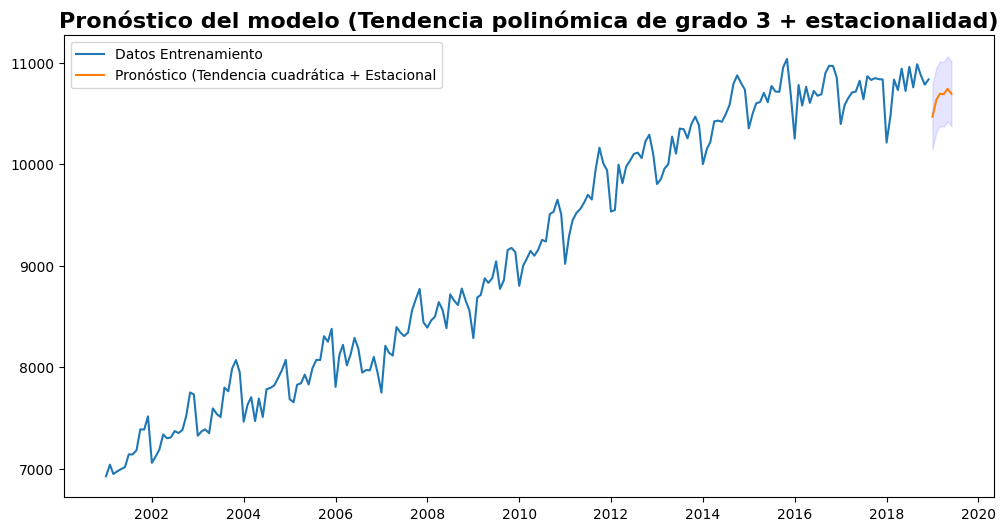

In [46]:
# Visual

fig = plt.figure(figsize=(12, 6))
plt.title("Pronóstico del modelo (Tendencia polinómica de grado 3 + estacionalidad)",fontsize=16, fontweight='bold')
plt.plot(y.index,y,label="Datos Entrenamiento")
plt.plot(preds.index,preds['Point_forecast'],label="Pronóstico (Tendencia cuadrática + Estacional")
plt.fill_between(preds.index,preds['lower_95'], preds['upper_95'], color='blue', alpha=0.1)
plt.legend()
plt.show()

Con el modelo ajustado, se procede a calcular el RMSE en el dataset de prueba.

In [47]:
# RMSE

rmse_estaci_lin3 = np.sqrt(mean_squared_error(test_td, y_prd_estaci_lin3))
print(f"RMSE del modelo tendencia polinómica orden 3 + Estacionalidad: {rmse_estaci_lin3:.4f}")

RMSE del modelo tendencia polinómica orden 3 + Estacionalidad: 104.6137


### **4.6 Tendencia polinómica (orden 4) + estacionalidad**

In [48]:
train_td["x4"] = train_td["x"] ** 4

# Matriz X con x, x2, x3, x4 y dummies
X_train = pd.concat([train_td[["x","x2","x3","x4"]],month_dummies.reindex(train_td.index)],axis=1)

# Añadir constante y asegurar float
X_train = sm.add_constant(X_train, has_constant="add").astype("float64")

In [49]:
# Ajuste OLS

y = train_td["Ocupados"]
X = X_train
Season_pol4 = sm.OLS(y,X)
Season_pol_4= Season_pol4.fit()
print(Season_pol_4.summary())

                            OLS Regression Results                            
Dep. Variable:               Ocupados   R-squared:                       0.990
Model:                            OLS   Adj. R-squared:                  0.990
Method:                 Least Squares   F-statistic:                     1366.
Date:                Sat, 08 Nov 2025   Prob (F-statistic):          2.08e-192
Time:                        14:16:34   Log-Likelihood:                -1351.8
No. Observations:                 216   AIC:                             2736.
Df Residuals:                     200   BIC:                             2790.
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       6751.7472     53.880    125.312      0.0

In [50]:
X

,const,x,x2,x3,x4,2,3,4,5,6,7,8,9,10,11,12
mes,,,,,,,,,,,,,,,,
2001-01-01,1.0,1.0,1.0,1.0,1.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2001-02-01,1.0,2.0,4.0,8.0,1.600000e+01,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2001-03-01,1.0,3.0,9.0,27.0,8.100000e+01,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2001-04-01,1.0,4.0,16.0,64.0,2.560000e+02,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2001-05-01,1.0,5.0,25.0,125.0,6.250000e+02,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-08-01,1.0,212.0,44944.0,9528128.0,2.019963e+09,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2018-09-01,1.0,213.0,45369.0,9663597.0,2.058346e+09,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2018-10-01,1.0,214.0,45796.0,9800344.0,2.097274e+09,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


Se grafican los residuales, se grafican los valores ajustados, y se realiza el pronóstico de los 6 meses con el modelo ajustado.

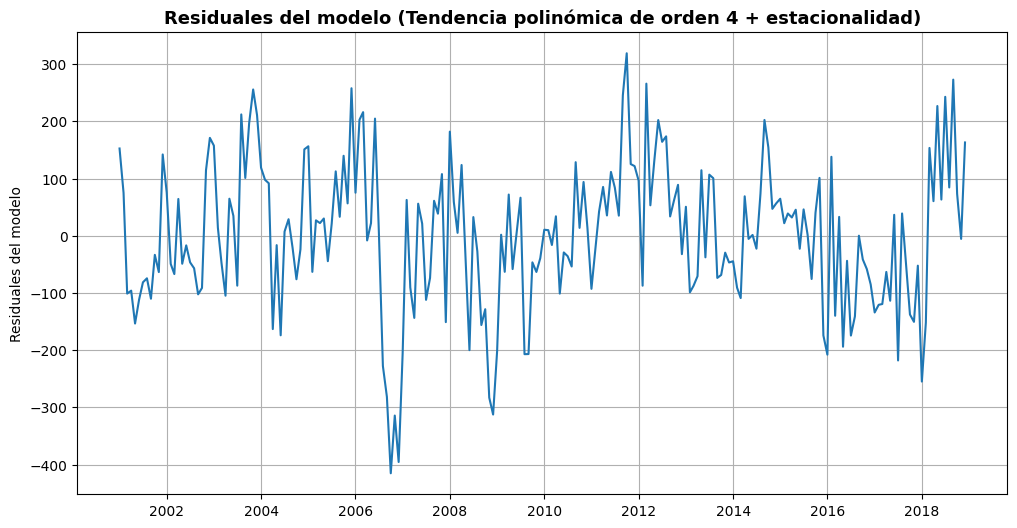

In [51]:
#Residuales

fig = plt.figure(figsize=(12, 6))
plt.title("Residuales del modelo (Tendencia polinómica de orden 4 + estacionalidad)",fontsize=13, fontweight='bold')
plt.ylabel("Residuales del modelo")
plt.plot(Season_pol_4.resid)
plt.grid()

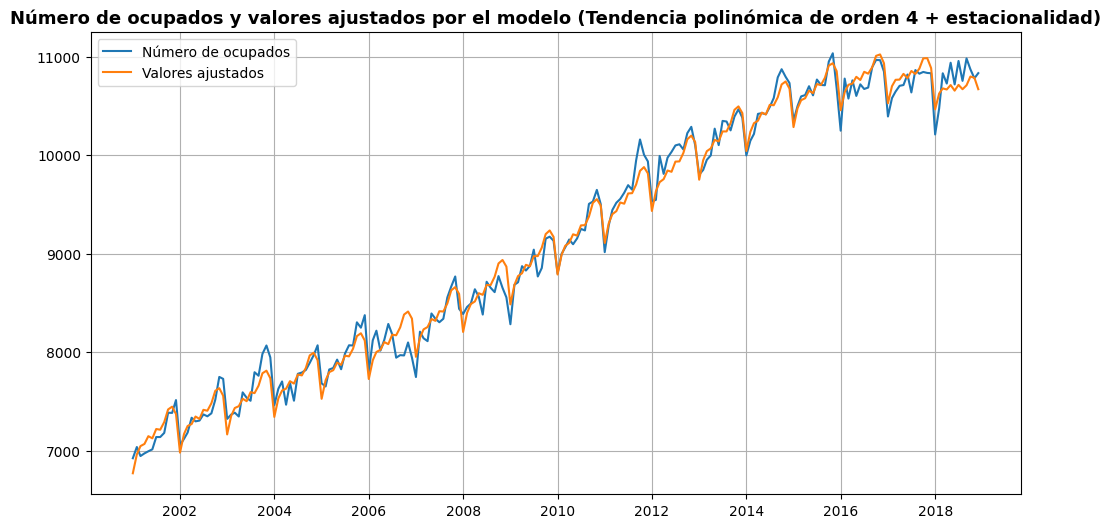

In [52]:
#Ajuste

fig = plt.figure(figsize=(12, 6))
plt.title("Número de ocupados y valores ajustados por el modelo (Tendencia polinómica de orden 4 + estacionalidad)",fontsize=13, fontweight='bold')
plt.plot(y,label="Número de ocupados")
plt.plot(Season_pol_4.fittedvalues,label="Valores ajustados")
plt.legend()
plt.grid()
plt.show()

In [53]:
# Pronóstico 6 meses

x_for= np.linspace((train_td.shape[0]+1),(train_td.shape[0]+h),h)

range_dates = pd.date_range(X_train.index[-1]+ relativedelta(months=1), periods=6,freq='MS')

x_for_all = pd.DataFrame(np.stack((x_for, x_for**2,x_for**3,x_for**4),axis=1), index=range_dates,columns=["x","x2","x3","x4"] )

x_for_dummies = pd.get_dummies(pd.Index(range_dates.month, name='month'), drop_first=True)
x_for_dummies.index = range_dates
x_for_dummies = x_for_dummies.astype("float64")


exog_cols = [c for c in Season_pol_4.model.exog_names if c != "const"]
trend_cols = [c for c in exog_cols if c in ("x","x2","x3","x4")]
dummy_cols = [c for c in exog_cols if c not in ("x","x2","x3","x4")]

x_for_dum = x_for_dummies.reindex(columns=dummy_cols, fill_value=0)

X_for = pd.concat([x_for_all[trend_cols], x_for_dum], axis=1).reindex(columns=exog_cols)
X_for = sm.add_constant(X_for, has_constant='add').astype('float64')

In [54]:
# Predicción

dt = Season_pol_4.get_prediction(X_for).summary_frame(alpha = 0.05)
y_prd_estaci_lin4 = dt['mean']
yprd_ci_lower = dt['obs_ci_lower']
yprd_ci_upper = dt['obs_ci_upper']
preds = pd.DataFrame(np.column_stack([y_prd_estaci_lin4, yprd_ci_lower, yprd_ci_upper]))
preds.columns = ['Point_forecast', 'lower_95', 'upper_95']
preds.set_index(range_dates,inplace=True)
print(preds)

            Point_forecast      lower_95      upper_95
2019-01-01    10237.729717   9956.652934  10518.806500
2019-02-01    10382.633184  10099.893153  10665.373215
2019-03-01    10418.936867  10134.370941  10703.502793
2019-04-01    10391.742547  10105.179006  10678.306088
2019-05-01    10420.185285  10131.443180  10708.927390
2019-06-01    10346.594529  10055.483563  10637.705495


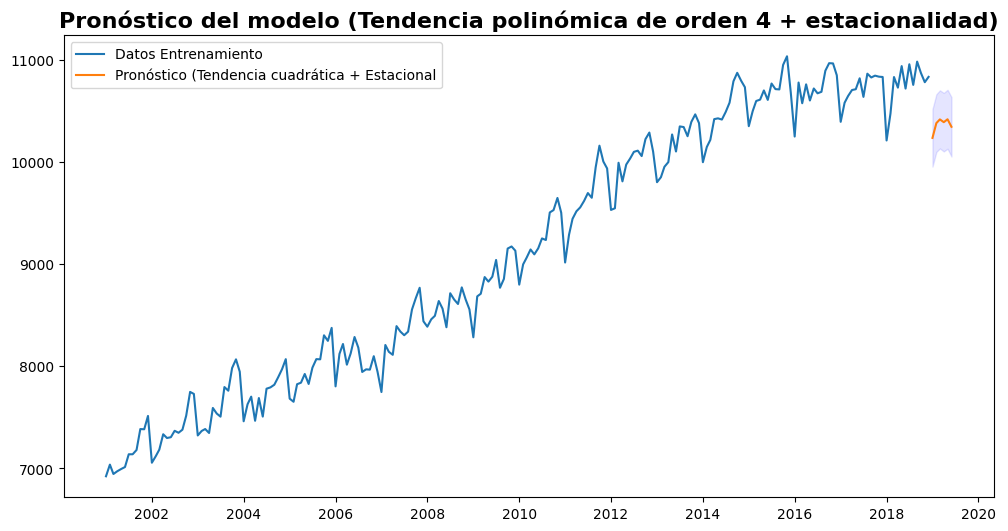

In [55]:
# Visual

fig = plt.figure(figsize=(12, 6))
plt.title("Pronóstico del modelo (Tendencia polinómica de orden 4 + estacionalidad)",fontsize=16, fontweight='bold')
plt.plot(y.index,y,label="Datos Entrenamiento")
plt.plot(preds.index,preds['Point_forecast'],label="Pronóstico (Tendencia cuadrática + Estacional")
plt.fill_between(preds.index,preds['lower_95'], preds['upper_95'], color='blue', alpha=0.1)
plt.legend()
plt.show()

Con el modelo ajustado, se procede a calcular el RMSE en el dataset de prueba.

In [56]:
# RMSE

rmse_estaci_lin4 = np.sqrt(mean_squared_error(test_td, y_prd_estaci_lin4))
print(f"RMSE del modelo cuadratico: {rmse_estaci_lin4:.4f}")

RMSE del modelo cuadratico: 320.6531


## **6. Elección del mejor modelo**

#### **Comparando modelos de distintos grados polinómicos**

In [57]:

# --- Configuración ---
target   = "Ocupados"
train_len = 216           # tu corte
degrees   = [2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20]     # cambia el rango a gusto
h         = 6             # pasos futuros (y también suele coincidir con largo de test)

# --- Features base: tendencia y mes para TODA la serie ---
df = data.copy()
df[target] = pd.to_numeric(df[target], errors="coerce")
df["x"]    = np.arange(1, len(df)+1)
df["month"]= df.index.month

train = df.iloc[:train_len].copy()
test  = df.iloc[train_len:].copy()      # si tu test tiene 6, perfecto

def poly_season_formula(target, max_deg):
    # y ~ x + x^2 + ... + x^max_deg + C(month)
    terms = " + ".join([f"I(x**{k})" for k in range(1, max_deg+1)])
    return f"{target} ~ {terms} + C(month)"

results = []

models_by_deg = {}
preds_test_by_deg = {}

for d in degrees:
    formula = poly_season_formula(target, d)
    model = smf.ols(formula, data=train).fit()
    y_true = test[target].astype(float)
    y_pred = model.predict(test)        # usa test['x'] y test['month']
    rmse   = np.sqrt(mean_squared_error(y_true, y_pred))
    results.append({"degree": d, "rmse_test": rmse})
    models_by_deg[d] = model
    preds_test_by_deg[d] = y_pred

# --- Tabla de RMSE y mejor grado ---
rmse_table = pd.DataFrame(results).sort_values("rmse_test")
best_deg   = rmse_table.iloc[0]["degree"]
best_model = models_by_deg[best_deg]

print(rmse_table)
print(f"\nMejor grado según RMSE test: d={int(best_deg)} (RMSE={rmse_table.iloc[0]['rmse_test']:.4f})")


    degree    rmse_test
1        3   104.613704
3        5   116.002471
4        6   118.746356
2        4   320.652982
0        2   519.225940
5        7  3748.743375
8       10  6054.738945
6        8  6126.291513
7        9  6192.922647
9       11  6219.143358
13      15  7536.112744
14      16  7683.288113
15      17  7689.684550
12      14  8010.798581
11      13  8095.984912
10      12  8127.710573
16      18  8546.466780
17      19  8617.897471
18      20  8690.597045

Mejor grado según RMSE test: d=3 (RMSE=104.6137)


Según el resultado anterior el mejor modelo es el modelo con tendencia polinómica de grado 3 + estacionalidad, que ya habiamos construido anteriormente

In [58]:
RMSE_modelos = { 'Modelo': ["Tendencia lineal", "Tendencia Cuadrática", "Estacionalidad", 'Tendencia cuadrática + estacionalidad', 'Tendencia polinómica de orden 3 + estacionalidad', 'Tendencia polinómica de orden 4 + estacionalidad'], 
                'RMSE': [rmse_lin, rmse_cuadri, rmse_estaci, rmse_estaci_lin2, rmse_estaci_lin3, rmse_estaci_lin4 ]}
RMSE_modelos_df = pd.DataFrame(RMSE_modelos)
RMSE_modelos_df = RMSE_modelos_df.sort_values(by='RMSE', ascending=True).reset_index(drop=True)
RMSE_modelos_df

,Modelo,RMSE
0,Tendencia polinómica de orden 3 + estacionalidad,104.613704
1,Tendencia polinómica de orden 4 + estacionalidad,320.653114
2,Tendencia cuadrática + estacionalidad,519.225940
3,Tendencia Cuadrática,632.476657
4,Tendencia lineal,725.528528
5,Estacionalidad,1685.766221


Según la tabla anterior, encontramos que el mejor modelo, que es el que reporta menor RMSE, es el modelo con **Tendencia polinómica de orden 3 + estacionalidad** el cual tiene un RMSE de **104.613704**. Así las cosas, después de hallar este modelo, haremos la comprobación de supuestos del modelo haciendo uso de todos los datos.

## **7. Comprobación de supuestos del mejor modelo**

Se re-entrena el mejor modelo (tendencia polinómica de orden 3 + estacionalidad) haciendo uso de todos los datos.

In [59]:
# Copia de seguridad

df = data.copy()

# Volvemos a crear dummies y splits para seguridad

month_dummies = pd.get_dummies(df.index.month,drop_first=True).set_index(df.index)

# Tendencia polinómio 3

df["x"] = np.linspace(1,df.shape[0],df.shape[0])
df["x2"] = df["x"] ** 2
df["x3"] = df["x"] ** 3

# Matriz X = [const, x, x2, dummies de mes]

X_ = pd.concat([df[["x","x2","x3"]],month_dummies],axis=1)
X = sm.add_constant(X_, has_constant="add").astype("float64")


In [60]:
# Ajuste OLS

y = df["Ocupados"]
modelo_final = sm.OLS(y, X).fit()
print(modelo_final.summary())

                            OLS Regression Results                            
Dep. Variable:               Ocupados   R-squared:                       0.987
Model:                            OLS   Adj. R-squared:                  0.987
Method:                 Least Squares   F-statistic:                     1158.
Date:                Sat, 08 Nov 2025   Prob (F-statistic):          4.96e-188
Time:                        14:16:36   Log-Likelihood:                -1420.0
No. Observations:                 222   AIC:                             2870.
Df Residuals:                     207   BIC:                             2921.
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       6971.9175     51.941    134.228      0.0

A continuación se comprueban cada uno de los supuestos del modelo.

### I) Normalidad de los residuos

In [61]:
residuals = modelo_final.resid
residuals_df = residuals.reset_index()
residuals_df.columns = ['Mes', 'Residuo']

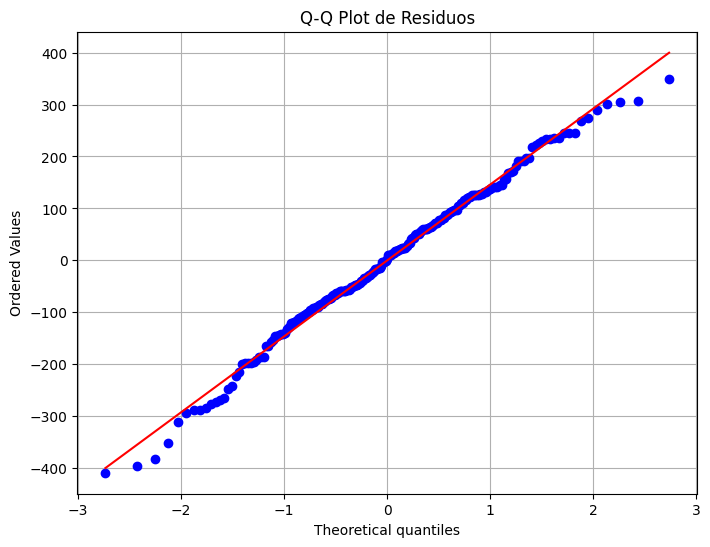

In [62]:
plt.figure(figsize=(8, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot de Residuos')
plt.grid(True)
plt.show()

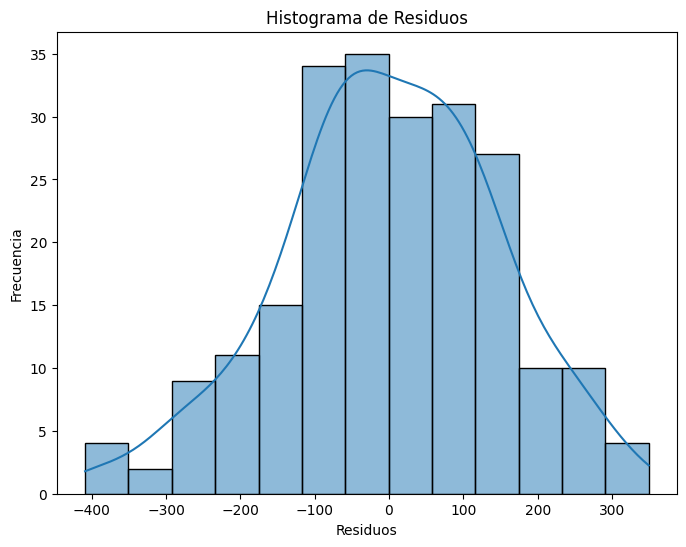

In [63]:
plt.figure(figsize=(8, 6))
sns.histplot(residuals, kde=True)
plt.xlabel('Residuos')
plt.ylabel('Frecuencia')
plt.title('Histograma de Residuos')
plt.show()

En el gráfico anterior se puede apreciar que la distribución presenta una simetría casi perfecta, lo anterior podría anticipar la existencia de normalidad en la distribución de los errores. Sin embargo, para confirmar esta sospecha, se procede a correr las pruebas de Jarque Bera y de Shapiro. En este caso, las pruebas de hipótesis de estas pruebas son las siguientes:

- H0: Los errores siguen una distribución normal
- H1: Los errores no siguen una distribución normal

In [64]:
shapiro_result = stats.shapiro(residuals_df.Residuo)
print(f"Resultados prueba Shapiro: {shapiro_result}")

Jarque_bera_result=stats.jarque_bera(residuals_df.Residuo)
print(f"Resultados prueba Jarque-Bera: {Jarque_bera_result}")

Resultados prueba Shapiro: ShapiroResult(statistic=np.float64(0.992597646582586), pvalue=np.float64(0.32989485316184763))
Resultados prueba Jarque-Bera: SignificanceResult(statistic=np.float64(1.9119126807417208), pvalue=np.float64(0.3844443090799362))


Al revisar la tabla anterior con los resultados del modelo, se puede evidenciar que los p-valores asociado a ambos test son mayores al nivel de significancia de 0.05, por lo que no se rechaza la hipótesis nula de normalidad. En este sentido, se evidencia que **los errores siguen una distribución normal**.

### II) Homocedasticidad de los residuos

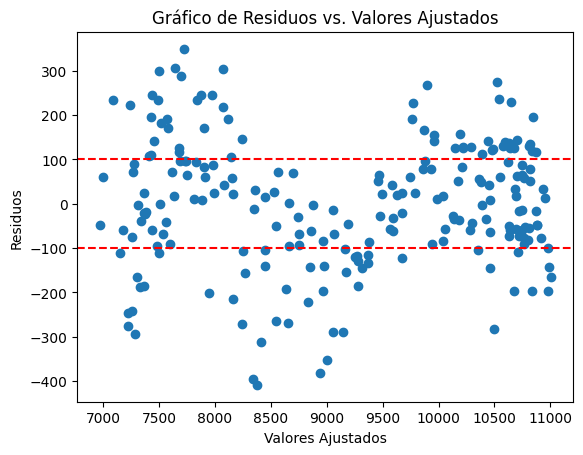

In [65]:
predicted=modelo_final.fittedvalues

plt.scatter(predicted, residuals)
plt.axhline(y=100, color='r', linestyle='--')
plt.axhline(y=-100, color='r', linestyle='--')
plt.xlabel('Valores Ajustados')
plt.ylabel('Residuos')
plt.title('Gráfico de Residuos vs. Valores Ajustados')
plt.show()

Se observa que los residuos no están distribuidos aleatoriamente, ya que presentan un patrón ondulado. Esto sugiere que el modelo no logra capturar completamente la estructura de los datos y que podría existir algún componente no considerado. Además, en ciertos tramos los residuos muestran una mayor dispersión, lo que indica heterocedasticidad. En consecuencia, los errores no presentan varianza constante, violando así el supuesto de homocedasticidad de los residuos.

Ahora nos queda por chequear lo anterior con una prueba estadística. Una aproximación para determinar si existe un comportamiento GARCH o ARCH es emplear la prueba de Ljung-Box sobre la serie (sin media) al cuadrado. Las hipótesis de esta prueba son las siguientes:

- H0: Comportamiento Homoscedastico (Es decir varianza constante) 
- H1: Comportamiento Heteroscedastico (Es decir varianza no constante)

In [66]:
sm.stats.acorr_ljungbox((residuals_df.Residuo-residuals_df.Residuo.mean())**2, lags=range(1,21), return_df=True,boxpierce=True )

,lb_stat,lb_pvalue,bp_stat,bp_pvalue
1,60.746869,6.490626e-15,59.933295,9.812734e-15
2,83.483715,7.442891e-19,82.264126,1.369532e-18
3,90.018301,2.170833e-19,88.652850,4.264647e-19
4,90.210109,1.188153e-18,88.839521,2.322673e-18
5,90.993164,4.155810e-18,89.598105,8.161018e-18
6,91.016798,1.862889e-17,89.620895,3.632252e-17
7,91.834696,5.193724e-17,90.405932,1.021137e-16
8,91.839452,1.967122e-16,90.410475,3.838449e-16
9,93.243649,3.630200e-16,91.745716,7.263306e-16
10,94.716822,6.184784e-16,93.139969,1.274138e-15


Todos los p-valores asociados a la prueba de Ljung-Box son menores a un nivel de significancia de 0.05. Por lo tanto, la evidencia permite rechazar la hipótesis nula de comportamiento homoscedástico (no auto-correlación de las varianzas), y por tanto **sí hay comportamiento ARCH o GARCH** en los residuos del modelo.

### III) Autocorrelación de los residuos

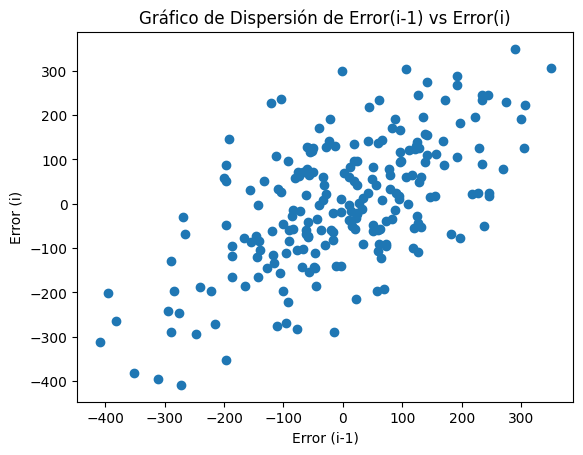

In [67]:
residuals_i_1 = residuals[:-1]
residuals_i = residuals[1:]

plt.scatter(residuals_i_1, residuals_i)
plt.title('Gráfico de Dispersión de Error(i-1) vs Error(i)')
plt.xlabel('Error (i-1)')
plt.ylabel('Error (i)')
plt.show()

En este caso, se puede realizar una primera aproximación gráfica a este supuesto. En el gráfico anterior se aprecia una posible existencia de correlación entre los errores, lo que sugiere que este supuesto podría no cumplirse. Sin embargo, para estar seguros, es necesario aplicar una prueba estadística que permita confirmar o descartar esta sospecha.

Para determinar si existe autocorrelación vamos a usar la prueba de rachas propuesta por Wald y Wolfowitz, 1940. Es una prueba no paramétrica donde las hipótesis son las siguientes:

$H{0}: ρ = 0$ (Es decir no hay autocorrelación) 

$H{1}: ρ \not= 0$ (Es decir hay autocorrelación)

Rechazo $H{0}$ cuando el p-valor es menor al nivel de significancia, convencionalmente se usa un $α$=0.05 ($α$ = nivel de significancia).

In [68]:
signo = residuals_df.Residuo>0
runstest_1samp(signo, correction=False)

(np.float64(-5.3806640999852045), np.float64(7.421155420013247e-08))

El segundo valor corresponde al p-valor=7.421155420013247e-08, por lo tanto considerando un $α$=0.05, los resultados obtenidos permiten rechazar la hipótesis nula, es decir, los residuos no parecen comportarse como un ruido blanco, es decir, **sí hay presencia de autocorrelación**. 

Este resultado se complementará con otras pruebas como la prueba de Box-Pierce y la modificación de Ljung-Box para muestras pequeñas.

In [69]:
# prueba de Box-Pierce y la modificación de Ljung-Box 
sm.stats.acorr_ljungbox(residuals_df.Residuo, lags=[1], return_df=True,boxpierce=True)

,lb_stat,lb_pvalue,bp_stat,bp_pvalue
1,86.348633,1.508528e-20,85.192178,2.707307e-20


Con el resultado anterior rechazamos la hipótesis nula de no autocorrelación para el primer rezago, lo ideal antes de tomar la decisión es probar por lo menos los primeros 20 rezagos.

In [70]:
Resul_lb_bp = sm.stats.acorr_ljungbox(residuals_df.Residuo, lags=range(1,21), return_df=True,boxpierce=True )
Resul_lb_bp["lb_ho"] = np.where(Resul_lb_bp['lb_pvalue']<0.05, 'rechazo_ho/hay_autocorr', 'no_rechazo_ho/no_hay_autocorr')
Resul_lb_bp["bp_ho"] = np.where(Resul_lb_bp['bp_pvalue']<0.05, 'rechazo_ho/hay_autocorr', 'no_rechazo_ho/no_hay_autocorr')
Resul_lb_bp

,lb_stat,lb_pvalue,bp_stat,bp_pvalue,lb_ho,bp_ho
1,86.348633,1.508528e-20,85.192178,2.707307e-20,rechazo_ho/hay_autocorr,rechazo_ho/hay_autocorr
2,155.169783,2.019807e-34,152.784379,6.657232e-34,rechazo_ho/hay_autocorr,rechazo_ho/hay_autocorr
3,210.756566,1.998343e-45,207.130386,1.214373e-44,rechazo_ho/hay_autocorr,rechazo_ho/hay_autocorr
4,242.507473,2.675675e-51,238.030822,2.463206e-50,rechazo_ho/hay_autocorr,rechazo_ho/hay_autocorr
5,262.850219,9.596852e-55,257.737857,1.201066e-53,rechazo_ho/hay_autocorr,rechazo_ho/hay_autocorr
6,279.813031,1.722767e-57,274.094854,2.884750e-56,rechazo_ho/hay_autocorr,rechazo_ho/hay_autocorr
7,291.667710,3.636541e-59,285.473230,7.632339e-58,rechazo_ho/hay_autocorr,rechazo_ho/hay_autocorr
8,301.043047,2.469799e-60,294.430025,6.308373e-59,rechazo_ho/hay_autocorr,rechazo_ho/hay_autocorr
9,313.165484,4.194617e-62,305.957163,1.421654e-60,rechazo_ho/hay_autocorr,rechazo_ho/hay_autocorr
10,320.933232,5.787015e-63,313.308782,2.380023e-61,rechazo_ho/hay_autocorr,rechazo_ho/hay_autocorr


El resultado es contundente, los residuos no parecen comportarse como un ruido blanco, esto confirma lo dictaminado por las anteriores pruebas y es que **sí hay presencia de autocorrelación**.

## **8. Comparación modelos lineales vs modelos de suavización exponencial**

### 8.1 Modelo con tendencia polinómica grado 3 y estacionalidad

In [71]:
# Volvemos a crear dummies y splits para seguridad

month_dummies = pd.get_dummies(data.index.month,drop_first=True).set_index(data.index)

train_len = 216
train_td = data[["Ocupados"]][:train_len]
test_td = data[["Ocupados"]][train_len:]

# Tendencia cuadrática en train

train_td["x"] = np.linspace(1,train_td.shape[0],train_td.shape[0])
train_td["x2"] = train_td["x"] ** 2
train_td["x3"] = train_td["x"] ** 3

# Matriz X = [const, x, x2, dummies de mes]

X_train = pd.concat([train_td[["x","x2","x3"]],month_dummies.reindex(train_td.index)],axis=1)
X_train = sm.add_constant(X_train, has_constant="add").astype("float64")


x_for= np.linspace((train_td.shape[0]+1),(train_td.shape[0]+h),h)

range_dates = pd.date_range(X_train.index[-1]+ relativedelta(months=1), periods=6,freq='MS')

x_for_all = pd.DataFrame(np.stack((x_for, x_for**2,x_for**3),axis=1), index=range_dates,columns=["x","x2","x3"] )

x_for_dummies = pd.get_dummies(pd.Index(range_dates.month, name='month'), drop_first=True)
x_for_dummies.index = range_dates
x_for_dummies = x_for_dummies.astype("float64")


exog_cols = [c for c in Season_pol_3.model.exog_names if c != "const"]
trend_cols = [c for c in exog_cols if c in ("x","x2","x3")]
dummy_cols = [c for c in exog_cols if c not in ("x","x2","x3")]

x_for_dum = x_for_dummies.reindex(columns=dummy_cols, fill_value=0)

X_for = pd.concat([x_for_all[trend_cols], x_for_dum], axis=1).reindex(columns=exog_cols)
X_for = sm.add_constant(X_for, has_constant='add').astype('float64')

dt = Season_pol_3.get_prediction(X_for).summary_frame(alpha = 0.05)
y_prd_estaci_lin_3 = dt['mean']
yprd_ci_lower = dt['obs_ci_lower']
yprd_ci_upper = dt['obs_ci_upper']
preds = pd.DataFrame(np.column_stack([y_prd_estaci_lin_3, yprd_ci_lower, yprd_ci_upper]))
preds.columns = ['Point_forecast', 'lower_95', 'upper_95']
preds.set_index(range_dates,inplace=True)
print(preds)


            Point_forecast      lower_95      upper_95
2019-01-01    10466.696419  10148.714218  10784.678619
2019-02-01    10633.804522  10315.146080  10952.462963
2019-03-01    10693.000988  10373.626992  11012.374984
2019-04-01    10689.406985  10369.276573  11009.537397
2019-05-01    10742.176957  10421.247701  11063.106213
2019-06-01    10693.659736  10371.887621  11015.431852


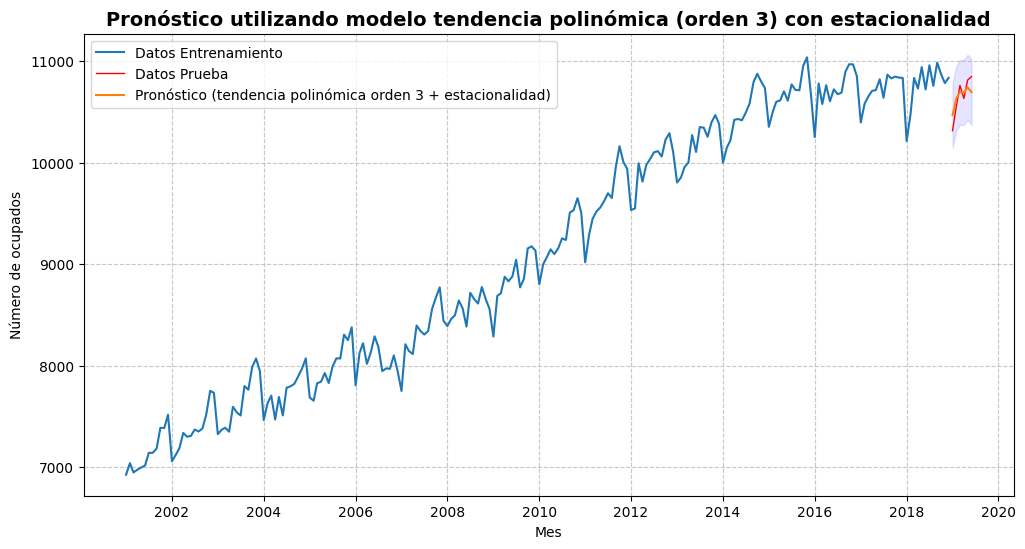

In [72]:
train_td_graph=train_td["Ocupados"]
test_td_graph=test_td["Ocupados"]

fig = plt.figure(figsize=(12, 6))
plt.title("Pronóstico utilizando modelo tendencia polinómica (orden 3) con estacionalidad", fontsize=14, fontweight='bold')
plt.plot(train_td_graph,label="Datos Entrenamiento")
plt.plot(test_td_graph, label="Datos Prueba", color='red', linewidth=1)
plt.plot(preds.index,preds['Point_forecast'],label="Pronóstico (tendencia polinómica orden 3 + estacionalidad)")
plt.xlabel("Mes")
plt.ylabel("Número de ocupados")
plt.fill_between(preds.index ,preds['lower_95'], preds['upper_95'], color='blue', alpha=0.1)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='upper left')
plt.show()

In [73]:
# Cálculo del RMSE en el conjunto de evaluación
rmse_test_modelo_final = np.sqrt(mean_squared_error(test_td, y_prd_estaci_lin_3))

print(f"RMSE del modelo con Tendencia polinómica de orden 3 + estacionalidad es igual a: {rmse_test_modelo_final:.4f}")

RMSE del modelo con Tendencia polinómica de orden 3 + estacionalidad es igual a: 104.6137


### 8.1 Modelo suavización exponencial Holt-Winters multiplicativo

In [74]:
train_len = 216
train_td = data[["Ocupados"]][:train_len]
test_td = data[["Ocupados"]][train_len:]

# Build model
ets_model = ETSModel(endog=train_td["Ocupados"],error="add", trend="mul", seasonal="mul", seasonal_periods=12, freq='MS')
ets_result = ets_model.fit()

point_forecast=ets_result.forecast(6)

ci = ets_result.get_prediction(start = point_forecast.index[0],
                                end = point_forecast.index[-1])

conf_forecast = ci.pred_int(alpha=0.05)
limits = ci.predicted_mean


preds_hw_add = pd.concat([limits, conf_forecast], axis = 1)
preds_hw_add.columns = ['Point_forecast', 'lower_95', 'upper_95']
print(preds_hw_add)

            Point_forecast      lower_95      upper_95
2019-01-01    10367.425903  10157.919332  10592.103013
2019-02-01    10585.339728  10339.743528  10838.974145
2019-03-01    10687.360261  10401.499369  10944.991132
2019-04-01    10715.093809  10403.258288  11023.775791
2019-05-01    10802.125310  10488.475478  11142.663355
2019-06-01    10775.756904  10428.355210  11139.392149


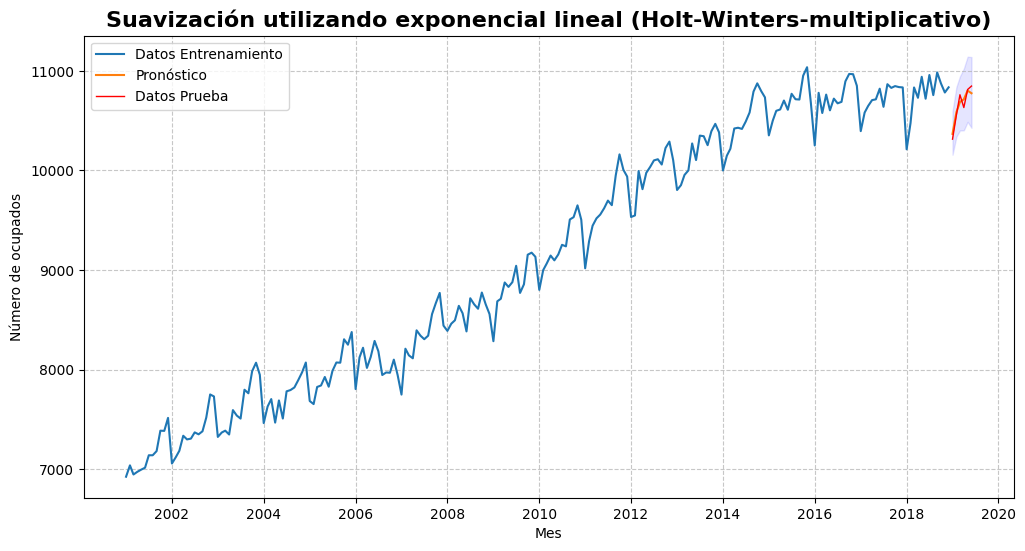

In [75]:
fig = plt.figure(figsize=(12, 6))
plt.title("Suavización utilizando exponencial lineal (Holt-Winters-multiplicativo)", fontsize=16, fontweight='bold')
plt.plot(train_td,label="Datos Entrenamiento")
plt.plot(preds_hw_add['Point_forecast'],label="Pronóstico")
plt.plot(test_td, label="Datos Prueba", color='red', linewidth=1)
plt.xlabel("Mes")
plt.ylabel("Número de ocupados")
plt.fill_between(preds_hw_add.index ,preds_hw_add['lower_95'], preds_hw_add['upper_95'], color='blue', alpha=0.1)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='upper left')
plt.show()

In [76]:
rmse_hw_mult = np.sqrt(mean_squared_error(test_td,preds_hw_add['Point_forecast']))
print(f"RMSE del modelo Holt-Winters con error aditivo, tendencia multiplicativa  y estacionalidad multiplicativa es igual a: {rmse_hw_mult:.4f}")

RMSE del modelo Holt-Winters con error aditivo, tendencia multiplicativa  y estacionalidad multiplicativa es igual a: 59.4234


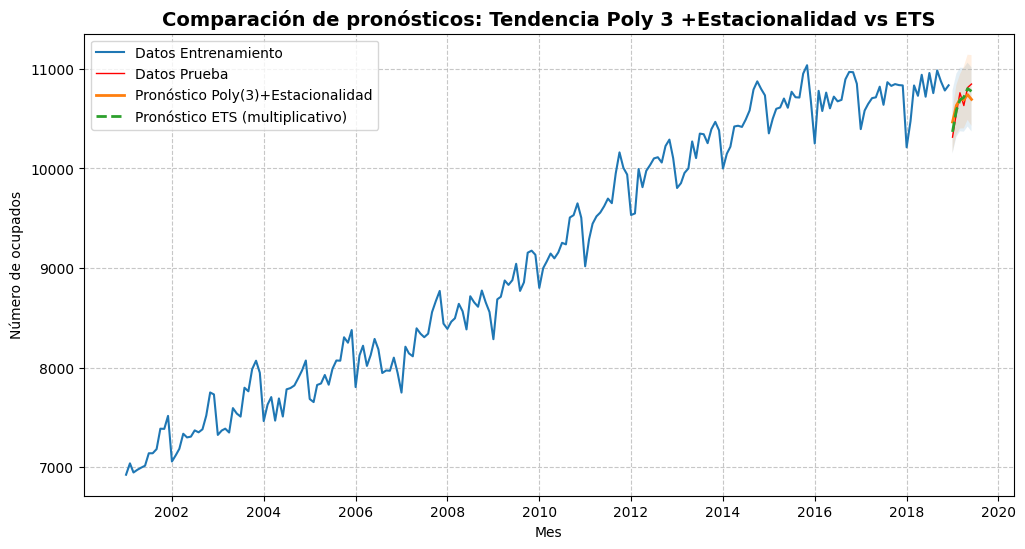

In [77]:
# Alinear ambos pronósticos por fecha
common_idx = preds.index.intersection(preds_hw_add.index)

poly_fc  = preds.loc[common_idx, 'Point_forecast']
ets_fc   = preds_hw_add.loc[common_idx, 'Point_forecast']

# (Opcional) Intervalos al 95% para cada modelo
poly_lo  = preds.loc[common_idx, 'lower_95']
poly_hi  = preds.loc[common_idx, 'upper_95']
ets_lo   = preds_hw_add.loc[common_idx, 'lower_95']
ets_hi   = preds_hw_add.loc[common_idx, 'upper_95']

# Gráfico conjunto
fig = plt.figure(figsize=(12, 6))
plt.title("Comparación de pronósticos: Tendencia Poly 3 +Estacionalidad vs ETS", fontsize=14, fontweight='bold')

# Series observadas
plt.plot(train_td.index, train_td["Ocupados"], label="Datos Entrenamiento")
plt.plot(test_td.index,  test_td["Ocupados"],  label="Datos Prueba", color='red', linewidth=1)

# Pronósticos
plt.plot(poly_fc.index, poly_fc, label="Pronóstico Poly(3)+Estacionalidad", linewidth=2)
plt.plot(ets_fc.index,  ets_fc,  label="Pronóstico ETS (multiplicativo)",  linewidth=2, linestyle='--')

# (Opcional) Bandas de confianza
plt.fill_between(poly_fc.index, poly_lo, poly_hi, alpha=0.12)
plt.fill_between(ets_fc.index,  ets_lo,  ets_hi,  alpha=0.12)

plt.xlabel("Mes")
plt.ylabel("Número de ocupados")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='best')
plt.show()


In [78]:
RMSE_modelos = { 'Modelo': ["Tendencia lineal", "Tendencia Cuadrática", "Estacionalidad", "Tendencia cuadrática + estacionalidad", "Tendencia polinómica de orden 3 + estacionalidad", "Tendencia polinómica de orden 4 + estacionalidad","Holt-Winters"], 
                'RMSE': [rmse_lin, rmse_cuadri, rmse_estaci, rmse_estaci_lin2, rmse_estaci_lin3, rmse_estaci_lin4, rmse_hw_mult ]}
RMSE_modelos_df = pd.DataFrame(RMSE_modelos)
RMSE_modelos_df = RMSE_modelos_df.sort_values(by='RMSE', ascending=True).reset_index(drop=True)
RMSE_modelos_df

,Modelo,RMSE
0,Holt-Winters,59.423406
1,Tendencia polinómica de orden 3 + estacionalidad,104.613704
2,Tendencia polinómica de orden 4 + estacionalidad,320.653114
3,Tendencia cuadrática + estacionalidad,519.225940
4,Tendencia Cuadrática,632.476657
5,Tendencia lineal,725.528528
6,Estacionalidad,1685.766221


A partir de la tabla anterior, se observa que los modelos con menor RMSE fueron el modelo con tendencia polinómica de orden 3 con estacionalidad y el modelo Holt-Winters (con error aditivo, tendencia multiplicativa y estacionalidad multiplicativa), cuyos RMSE fueron 104.61 y 59.42, respectivamente. Evidentemente, el modelo que mejor se ajusta a los datos es el Holt-Winters.

Aunque el modelo con tendencia polinómica presenta el menor RMSE entre los modelos de regresión lineal, incumple dos supuestos fundamentales sobre los residuos —homocedasticidad y no autocorrelación—, además de no alcanzar el nivel de precisión obtenido por el modelo de suavización exponencial de Holt-Winters.

Dado lo anterior se elige el modelo Holt-Winters para realizar el pronóstico, el cual, se presenta a continuación.

In [79]:
## Se obtienen los hiperparametros

alpha_value = ets_result.alpha
beta_value = ets_result.beta
gamma_value = ets_result.gamma

In [80]:
final_model = ETSModel(endog=data["Ocupados"],error="add", trend="mul", seasonal="mul", seasonal_periods=12, freq='MS')

final_model_fit = final_model.fit_constrained({
    'smoothing_level': alpha_value,
    'smoothing_trend': beta_value,
    'smoothing_seasonal': gamma_value
})

point_forecast=final_model_fit.forecast(6)

ci = final_model_fit.get_prediction(start = point_forecast.index[0],
                                end = point_forecast.index[-1])

conf_forecast = ci.pred_int(alpha=0.05)#.iloc[:,0]
limits = ci.predicted_mean


preds_hw_final = pd.concat([limits, conf_forecast], axis = 1)
preds_hw_final.columns = ['Pronóstico puntual', 'lower_95', 'upper_95']
print(preds_hw_final)

            Pronóstico puntual      lower_95      upper_95
2019-07-01        10915.692073  10701.567904  11143.820432
2019-08-01        10904.064814  10652.760186  11152.431211
2019-09-01        10997.716483  10731.613400  11281.400284
2019-10-01        11140.582549  10824.604923  11429.083322
2019-11-01        11165.789038  10859.422823  11491.804899
2019-12-01        11070.065860  10714.774066  11405.410493


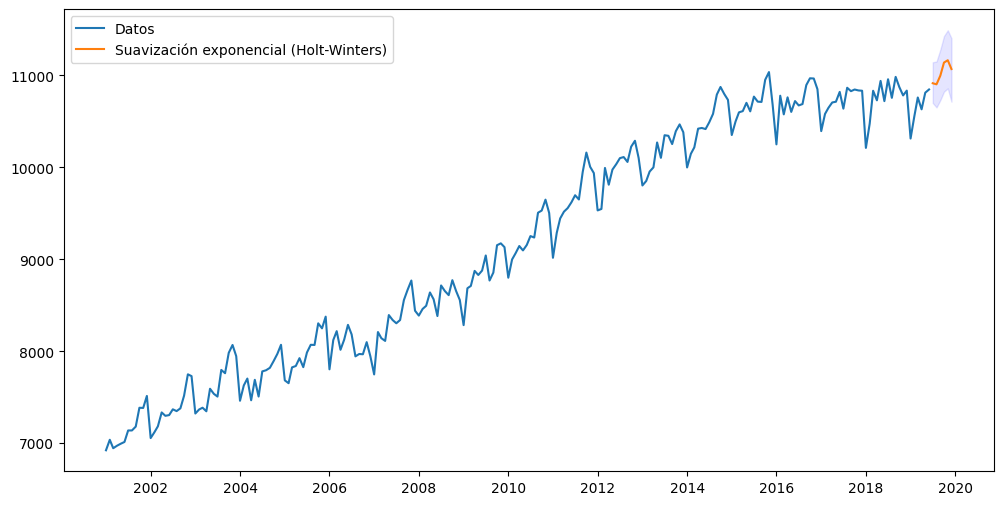

In [81]:
fig = plt.figure(figsize=(12, 6))
plt.plot(data["Ocupados"],label="Datos")
plt.plot(preds_hw_final['Pronóstico puntual'],label="Suavización exponencial (Holt-Winters)")
plt.fill_between(preds_hw_final.index ,preds_hw_final['lower_95'], preds_hw_final['upper_95'], color='blue', alpha=0.1)
plt.legend()
plt.show()